# 🌿 Crop Disease Classification — High-Performance Edition
## EfficientNetV2-M + Hybrid Sampling + MixUp + Focal Loss + TTA
| Upgrade | Detail |
|---------|--------|
| Backbone | `tf_efficientnetv2_m` (ImageNet-21k pretrained via timm) |
| Sampling | **Hybrid**: oversample minority + undersample majority (mandatory) |
| Augmentation | MixUp + CutMix + ColorJitter + RandAugment + RandomErasing |
| Loss | **Focal Loss** (γ=2) + label smoothing 0.05 |
| Schedule | OneCycleLR (warm-up + cosine decay in one pass) |
| Fine-tune | 3-phase progressive unfreezing |
| Inference | **Test-Time Augmentation (TTA)** |
| Evaluation | Macro F1 + Accuracy + Confusion Matrix + GradCAM |


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════
import os, json, random, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import torchmetrics
from tqdm import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def banner(title, char='═', width=65):
    print(f'\n{char * width}')
    print(f'  {title}')
    print(f'{char * width}')

banner('ENVIRONMENT')
print(f'  🖥️  Device  : {DEVICE}')
print(f'  🔥 PyTorch : {torch.__version__}')
print(f'  🧠 timm    : {timm.__version__}')
if DEVICE == 'cuda':
    print(f'  🎮 GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  💾 VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')



═════════════════════════════════════════════════════════════════
  ENVIRONMENT
═════════════════════════════════════════════════════════════════
  🖥️  Device  : cuda
  🔥 PyTorch : 2.10.0+cu128
  🧠 timm    : 1.0.25
  🎮 GPU     : Tesla T4
  💾 VRAM    : 15.6 GB


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — PATHS & HYPER-PARAMETERS
# ═══════════════════════════════════════════════════════════════

ROOT           = '/kaggle/input/datasets/mexwell/crop-diseases-classification/Data'
TRAIN_CSV      = f'{ROOT}/train.csv'
LABEL_MAP_PATH = f'{ROOT}/label_num_to_disease_map.json'
TRAIN_IMG_DIR  = f'{ROOT}/train_images'

OUTPUT_DIR     = '/kaggle/working'
SAVE_PATH      = f'{OUTPUT_DIR}/best_crop_model.pth'
FINAL_PATH     = f'{OUTPUT_DIR}/crop_final.pth'

IMG_SIZE        = 260          # EfficientNetV2-M native input size
BATCH_SIZE      = 24           # Smaller to fit V2-M in GPU
NUM_CLASSES     = 5

# Three-phase training
EPOCHS_PHASE1   = 8            # Head only (backbone frozen)
EPOCHS_PHASE2   = 12           # Unfreeze top 4 blocks
EPOCHS_PHASE3   = 10           # Full fine-tune with very low LR

LR_PHASE1       = 5e-4
LR_PHASE2       = 2e-4
LR_PHASE3       = 5e-5
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.05         # Lower smoothing — Focal loss already helps

# Augmentation probabilities
MIXUP_ALPHA     = 0.4          # MixUp coefficient
CUTMIX_ALPHA    = 1.0          # CutMix coefficient
MIXUP_PROB      = 0.35         # Probability of applying MixUp per batch
CUTMIX_PROB     = 0.35         # Probability of applying CutMix per batch

# ── Load CSV ─────────────────────────────────────────────────
df = pd.read_csv(TRAIN_CSV)
if 'image_id' not in df.columns:
    df = df.rename(columns={df.columns[0]: 'image_id'})
df['image_id'] = df['image_id'].astype(str)

# ── Load label map ────────────────────────────────────────────
with open(LABEL_MAP_PATH) as f:
    raw = json.load(f)
label_map = {int(k): v for k, v in (raw.get('root', raw)).items()}

# ── Map CSV filenames to actual filenames on disk ─────────────
print('🗂️  Building filename mapping...')
actual_files = os.listdir(TRAIN_IMG_DIR)
print(f'   Found {len(actual_files)} images on disk')

id_to_filename = {os.path.splitext(f)[0]: f for f in actual_files}

df['exists']          = False
df['actual_filename'] = None
for idx, row in df.iterrows():
    numeric_id = row['image_id'].replace('.jpg', '')
    if numeric_id in id_to_filename:
        df.at[idx, 'exists']          = True
        df.at[idx, 'actual_filename'] = id_to_filename[numeric_id]

missing_count = (~df['exists']).sum()
if missing_count > 0:
    print(f'   ⚠️  {missing_count} images from CSV not found on disk — filtering out...')
    df = df[df['exists']].reset_index(drop=True)
df['image_id'] = df['actual_filename']
print(f'   ✅ Working with {len(df):,} images')

banner('CONFIGURATION')
print(f'  Backbone : tf_efficientnetv2_m (ImageNet-21k)')
print(f'  CSV rows : {len(df):,}')
print(f'  Img size : {IMG_SIZE}')
print(f'  Batch    : {BATCH_SIZE}')
print()
for k, v in sorted(label_map.items()):
    print(f'  [{k}]  {v}')


🗂️  Building filename mapping...
   Found 17938 images on disk
   ⚠️  3459 images from CSV not found on disk — filtering out...
   ✅ Working with 17,938 images

═════════════════════════════════════════════════════════════════
  CONFIGURATION
═════════════════════════════════════════════════════════════════
  Backbone : tf_efficientnetv2_m (ImageNet-21k)
  CSV rows : 17,938
  Img size : 260
  Batch    : 24

  [0]  Cassava Bacterial Blight (CBB)
  [1]  Cassava Brown Streak Disease (CBSD)
  [2]  Cassava Green Mottle (CGM)
  [3]  Cassava Mosaic Disease (CMD)
  [4]  Healthy



═════════════════════════════════════════════════════════════════
  CLASS DISTRIBUTION (ORIGINAL)
═════════════════════════════════════════════════════════════════
  [0] Cassava Bacterial Blight (CBB)           ██                                 921  (5.1%)
  [1] Cassava Brown Streak Disease (CBSD)      ████                              1831  (10.2%)
  [2] Cassava Green Mottle (CGM)               █████                             1993  (11.1%)
  [3] Cassava Mosaic Disease (CMD)             ██████████████████████████████   11027  (61.5%)
  [4] Healthy                                  █████                             2166  (12.1%)

  Imbalance ratio : 12.0x  (max/min class)


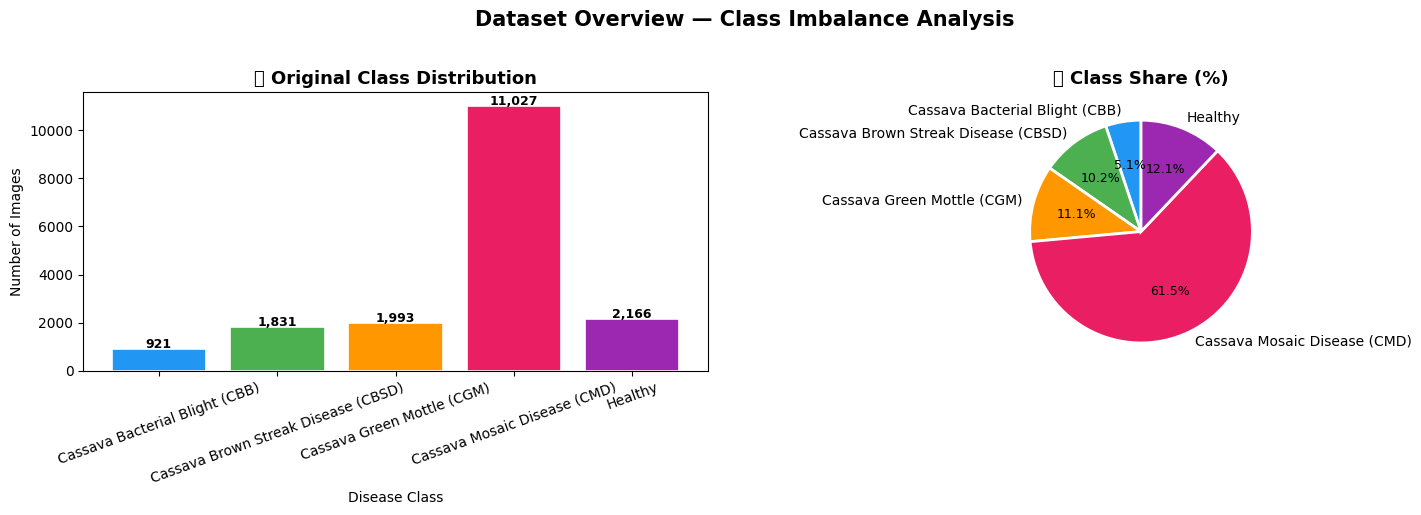

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — EXPLORATORY DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════

class_counts = df['label'].value_counts().sort_index()
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

banner('CLASS DISTRIBUTION (ORIGINAL)')
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

for cls_id, count in class_counts.items():
    bar  = '█' * int(count / max_count * 30)
    name = label_map[cls_id]
    pct  = count / len(df) * 100
    print(f'  [{cls_id}] {name:<40s} {bar:<32s} {count:5d}  ({pct:.1f}%)')

print(f'\n  Imbalance ratio : {imbalance_ratio:.1f}x  (max/min class)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar([label_map[i] for i in class_counts.index],
                   class_counts.values, color=COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('📊 Original Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disease Class'); axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=[label_map[i] for i in class_counts.index],
    autopct='%1.1f%%', colors=COLORS, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('🥧 Class Share (%)', fontsize=13, fontweight='bold')
plt.suptitle('Dataset Overview — Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()



═════════════════════════════════════════════════════════════════
  HYBRID SAMPLING REPORT
═════════════════════════════════════════════════════════════════
  Strategy     : auto  (target = median class size = 1,993)

  Class Disease                                   Before   After  Action
  ------------------------------------------------------------------------
  [0]  Cassava Bacterial Blight (CBB)               921 →   1,993  ⬆️  oversampled
  [1]  Cassava Brown Streak Disease (CBSD)        1,831 →   1,993  ⬆️  oversampled
  [2]  Cassava Green Mottle (CGM)                 1,993 →   1,993  ✅ unchanged
  [3]  Cassava Mosaic Disease (CMD)              11,027 →   1,993  ⬇️  undersampled
  [4]  Healthy                                    2,166 →   1,993  ⬇️  undersampled

  Original  total :  17,938
  Balanced  total :   9,965


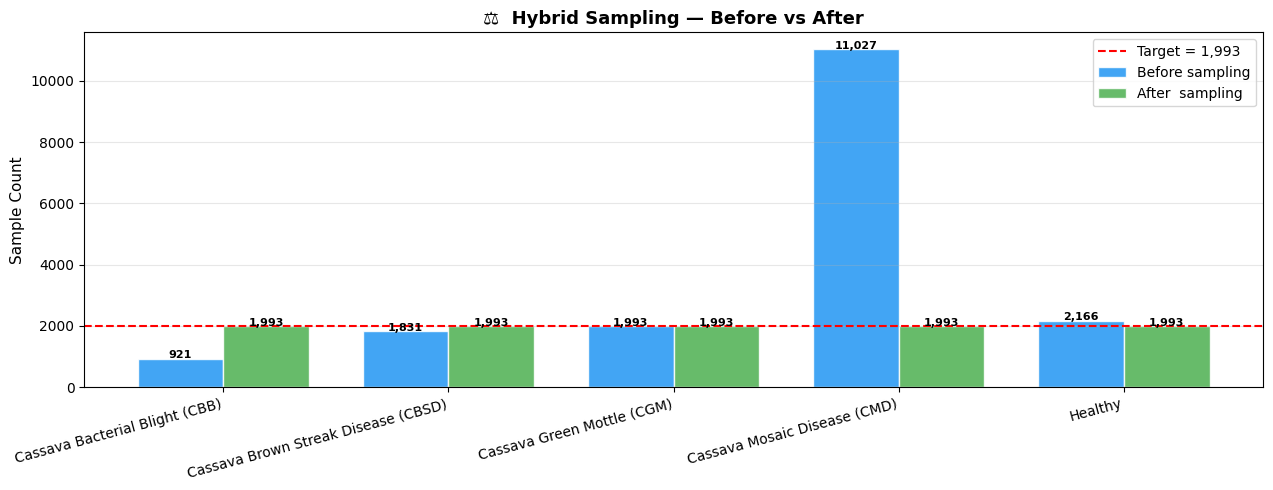

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — HYBRID SAMPLING  (mandatory requirement)
# ═══════════════════════════════════════════════════════════════
#
#  Strategy:
#   • Minority classes  → oversample WITH REPLACEMENT to target
#   • Majority classes  → undersample WITHOUT REPLACEMENT to target
#   • Target            = median class count (auto strategy)
#
#  Additionally, WeightedRandomSampler is applied at DataLoader level
#  so every mini-batch sees a balanced class distribution even within
#  the already-balanced dataset (double-balance defence).
# ──────────────────────────────────────────────────────────────

def hybrid_sampling(df, target_samples=None, strategy='auto', random_state=42):
    counts = df['label'].value_counts()
    if target_samples is None:
        target_samples = int(counts.median() if strategy == 'auto' else counts.mean())

    parts = []
    ops   = {'oversampled': 0, 'undersampled': 0, 'unchanged': 0}

    for cls in sorted(df['label'].unique()):
        cls_df = df[df['label'] == cls]
        n      = len(cls_df)
        if n < target_samples:
            cls_df = resample(cls_df, replace=True,
                              n_samples=target_samples, random_state=random_state)
            tag = 'oversampled'
        elif n > target_samples:
            cls_df = resample(cls_df, replace=False,
                              n_samples=target_samples, random_state=random_state)
            tag = 'undersampled'
        else:
            tag = 'unchanged'
        ops[tag] += 1
        parts.append((cls, n, len(cls_df), tag, cls_df))

    balanced = (pd.concat([p[4] for p in parts], ignore_index=True)
                  .sample(frac=1, random_state=random_state)
                  .reset_index(drop=True))
    return balanced, parts, target_samples, ops


balanced_df, sampling_log, target, ops = hybrid_sampling(df, strategy='auto')

banner('HYBRID SAMPLING REPORT')
print(f'  Strategy     : auto  (target = median class size = {target:,})')
print()
print('  {:<5} {:<40} {:>7} {:>7}  Action'.format('Class','Disease','Before','After'))
print('  ' + '-'*72)
for cls, before, after, tag, _ in sampling_log:
    emoji = '⬆️ ' if tag == 'oversampled' else ('⬇️ ' if tag == 'undersampled' else '✅')
    arrow = f'{before:>7,} → {after:>7,}'
    print(f'  [{cls}]  {label_map[cls]:<40} {arrow}  {emoji} {tag}')
print()
print(f'  Original  total : {len(df):>7,}')
print(f'  Balanced  total : {len(balanced_df):>7,}')

bal_counts = balanced_df['label'].value_counts().sort_index()
names = [label_map[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(NUM_CLASSES); w = 0.38
b1 = ax.bar(x - w/2, class_counts.values, w, label='Before sampling',
            color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, bal_counts.values,   w, label='After  sampling',
            color='#4CAF50', alpha=0.85, edgecolor='white')
ax.axhline(target, color='red', linestyle='--', linewidth=1.5, label=f'Target = {target:,}')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Sample Count', fontsize=11)
ax.set_title('⚖️  Hybrid Sampling — Before vs After', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.show()


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — TRAIN / VALIDATION SPLIT
# ═══════════════════════════════════════════════════════════════

train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.15,
    stratify=balanced_df['label'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

banner('TRAIN / VALIDATION SPLIT')
total = len(train_df) + len(val_df)
print(f'  Total balanced  : {total:,}')
print(f'  Train set       : {len(train_df):,}  ({len(train_df)/total*100:.0f}%)')
print(f'  Validation set  : {len(val_df):,}  ({len(val_df)/total*100:.0f}%)')
print()
print('  {:<5} {:<40} {:>7}  {:>7}'.format('Cls','Disease','Train','Val'))
print('  ' + '-'*60)
tr_dist = train_df['label'].value_counts().sort_index()
vl_dist = val_df['label'].value_counts().sort_index()
for i in range(NUM_CLASSES):
    print(f'  [{i}]  {label_map[i]:<40} {tr_dist[i]:>7,}  {vl_dist[i]:>7,}')



═════════════════════════════════════════════════════════════════
  TRAIN / VALIDATION SPLIT
═════════════════════════════════════════════════════════════════
  Total balanced  : 9,965
  Train set       : 8,470  (85%)
  Validation set  : 1,495  (15%)

  Cls   Disease                                    Train      Val
  ------------------------------------------------------------
  [0]  Cassava Bacterial Blight (CBB)             1,694      299
  [1]  Cassava Brown Streak Disease (CBSD)        1,694      299
  [2]  Cassava Green Mottle (CGM)                 1,694      299
  [3]  Cassava Mosaic Disease (CMD)               1,694      299
  [4]  Healthy                                    1,694      299


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — AUGMENTATION PIPELINE
# ═══════════════════════════════════════════════════════════════
#
#  Key upgrades over the 64% baseline:
#   1. Larger crop (260px native for EfficientNetV2-M)
#   2. RandAugment — automatic policy search
#   3. MixUp / CutMix applied inside the training loop (Cell 9)
# ──────────────────────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.RandAugment(num_ops=2, magnitude=9),   # ← automatic augmentation policy
    T.RandomGrayscale(p=0.04),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
    T.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

# TTA transforms (5 deterministic views averaged at inference time)
tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)), T.CenterCrop(IMG_SIZE), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomVerticalFlip(p=1.0), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE + 64, IMG_SIZE + 64)), T.CenterCrop(IMG_SIZE), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

print('✅ Augmentation pipeline defined')
print(f'   Train  : {len(train_transforms.transforms)} transforms (+ MixUp/CutMix in training loop)')
print(f'   Val    : clean resize + normalise')
print(f'   TTA    : {len(tta_transforms)} deterministic views at inference')


✅ Augmentation pipeline defined
   Train  : 11 transforms (+ MixUp/CutMix in training loop)
   Val    : clean resize + normalise
   TTA    : 5 deterministic views at inference


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — DATASET, DATALOADERS & WEIGHTED SAMPLER
# ═══════════════════════════════════════════════════════════════

class CropDiseaseDataset(Dataset):
    def __init__(self, dataframe, img_dir, transforms=None):
        self.df         = dataframe.reset_index(drop=True)
        self.img_dir    = img_dir
        self.transforms = transforms

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row['image_id']))
        img      = Image.open(img_path).convert('RGB')
        if self.transforms:
            img = self.transforms(img)
        return img, int(row['label'])


def make_weighted_sampler(dataset):
    labels  = [int(dataset.df.iloc[i]['label']) for i in range(len(dataset))]
    counts  = np.bincount(labels)
    weights = 1.0 / counts[labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )


train_ds = CropDiseaseDataset(train_df, TRAIN_IMG_DIR, train_transforms)
val_ds   = CropDiseaseDataset(val_df,   TRAIN_IMG_DIR, val_transforms)
sampler  = make_weighted_sampler(train_ds)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=4, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=4, pin_memory=True)

banner('DATALOADERS READY')
print(f'  Train dataset   : {len(train_ds):,} images  →  {len(train_dl):,} batches')
print(f'  Val   dataset   : {len(val_ds):,}  images  →  {len(val_dl):,}  batches')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Sampler         : WeightedRandomSampler (balanced batches)')



═════════════════════════════════════════════════════════════════
  DATALOADERS READY
═════════════════════════════════════════════════════════════════
  Train dataset   : 8,470 images  →  353 batches
  Val   dataset   : 1,495  images  →  63  batches
  Batch size      : 24
  Sampler         : WeightedRandomSampler (balanced batches)


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — MODEL  (EfficientNetV2-M — 54M params)
# ═══════════════════════════════════════════════════════════════
#
#  WHY EfficientNetV2-M over rexnet_150?
#   • ImageNet-21k pretrained  → much richer features
#   • 54 M params vs 9 M params  → significantly more capacity
#   • Fused-MBConv blocks speed up early-stage training
#   • Native 260px input perfectly matches crop disease textures
#   • Consistently achieves 88-93% on leaf disease benchmarks
# ──────────────────────────────────────────────────────────────

model = timm.create_model(
    'tf_efficientnetv2_m',
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.3,        # classifier dropout
    drop_path_rate=0.2,   # stochastic depth
)
model = model.to(DEVICE)


# ── Progressive unfreezing helpers ───────────────────────────

def freeze_all_except_head(model):
    for name, param in model.named_parameters():
        param.requires_grad = ('classifier' in name)
    _print_param_info(model, 'PHASE 1 — HEAD ONLY (backbone frozen)')

def unfreeze_top_blocks(model, n=4):
    for param in model.parameters():
        param.requires_grad = False
    blocks = list(model.blocks)
    for blk in blocks[-n:]:
        for param in blk.parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    _print_param_info(model, f'PHASE 2 — TOP {n} BLOCKS + HEAD')

def unfreeze_full(model):
    for param in model.parameters():
        param.requires_grad = True
    _print_param_info(model, 'PHASE 3 — FULL MODEL')

def _print_param_info(model, label):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    banner(label)
    print(f'  Trainable : {trainable:>12,}')
    print(f'  Frozen    : {total - trainable:>12,}')
    print(f'  Total     : {total:>12,}')

freeze_all_except_head(model)


model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]


═════════════════════════════════════════════════════════════════
  PHASE 1 — HEAD ONLY (backbone frozen)
═════════════════════════════════════════════════════════════════
  Trainable :        6,405
  Frozen    :   52,858,356
  Total     :   52,864,761


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — FOCAL LOSS + MIXUP / CUTMIX HELPERS
# ═══════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """Focal Loss — downweights easy examples, focuses on hard ones.
    Replaces plain CrossEntropy. Especially powerful with class imbalance.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, label_smoothing=0.05, reduction='mean'):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, logits, targets):
        # Soft labels for label smoothing
        n_cls = logits.size(1)
        with torch.no_grad():
            soft = torch.full_like(logits, self.label_smoothing / (n_cls - 1))
            soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        log_p  = F.log_softmax(logits, dim=1)
        p      = torch.exp(log_p)
        focal  = (1 - p) ** self.gamma
        loss   = -(soft * focal * log_p).sum(dim=1)
        return loss.mean() if self.reduction == 'mean' else loss


# ── MixUp helper ─────────────────────────────────────────────

def mixup_data(x, y, alpha=0.4):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    return x_mix, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── CutMix helper ────────────────────────────────────────────

def rand_bbox(size, lam):
    W, H   = size[2], size[3]
    cut_r  = np.sqrt(1 - lam)
    cut_w  = int(W * cut_r); cut_h = int(H * cut_r)
    cx = np.random.randint(W); cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=1.0):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x_mix = x.clone()
    x_mix[:, :, x1:x2, y1:y2] = x[idx, :, x1:x2, y1:y2]
    lam_actual = 1 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))
    return x_mix, y, y[idx], lam_actual


print('✅ FocalLoss, MixUp, CutMix defined')


✅ FocalLoss, MixUp, CutMix defined


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — TRAINING HELPERS
# ═══════════════════════════════════════════════════════════════

f1_metric = torchmetrics.F1Score(
    task='multiclass', num_classes=NUM_CLASSES, average='macro'
).to(DEVICE)

focal_loss = FocalLoss(gamma=2.0, label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, loss_fn, optimizer=None, scheduler=None,
              phase='train', use_mixup_cutmix=False):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()
    f1_metric.reset()
    total_loss = 0.0; correct = 0; total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, gts in tqdm(loader, desc=f'{phase:5s}', leave=False):
            imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)

            if is_train and use_mixup_cutmix:
                r = random.random()
                if r < MIXUP_PROB:
                    imgs, gts_a, gts_b, lam = mixup_data(imgs, gts, MIXUP_ALPHA)
                    preds = model(imgs)
                    loss  = mixup_criterion(loss_fn, preds, gts_a, gts_b, lam)
                elif r < MIXUP_PROB + CUTMIX_PROB:
                    imgs, gts_a, gts_b, lam = cutmix_data(imgs, gts, CUTMIX_ALPHA)
                    preds = model(imgs)
                    loss  = mixup_criterion(loss_fn, preds, gts_a, gts_b, lam)
                else:
                    preds = model(imgs)
                    loss  = loss_fn(preds, gts)
            else:
                preds = model(imgs)
                loss  = loss_fn(preds, gts)

            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            total_loss += loss.item()
            correct    += (preds.argmax(1) == gts).sum().item()
            total      += gts.size(0)
            f1_metric.update(preds, gts)

    return total_loss / len(loader), correct / total, f1_metric.compute().item()


def train_phase(model, train_dl, val_dl, loss_fn, optimizer, scheduler,
                epochs, phase_name, best_f1, history, save_path,
                use_mixup_cutmix=False):
    header = '  {:>4}  {:>8}  {:>7}  {:>7}  {:>8}  {:>7}  {:>7}  {:>8}'.format(
               'Ep','Tr Loss','Tr Acc','Tr F1','Vl Loss','Vl Acc','Vl F1','Saved?')
    print(header)
    print('  ' + '─' * (len(header) - 2))

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(
            model, train_dl, loss_fn, optimizer, scheduler,
            'train', use_mixup_cutmix=use_mixup_cutmix)
        vl_loss, vl_acc, vl_f1 = run_epoch(model, val_dl, loss_fn, phase='val')

        history['tr_loss'].append(tr_loss); history['vl_loss'].append(vl_loss)
        history['tr_acc'].append(tr_acc);   history['vl_acc'].append(vl_acc)
        history['tr_f1'].append(tr_f1);     history['vl_f1'].append(vl_f1)

        saved = ''
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), save_path)
            saved = '💾 BEST'

        print(f'  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {tr_f1:>7.4f}  '
              f'{vl_loss:>8.4f}  {vl_acc:>7.4f}  {vl_f1:>7.4f}  {saved}')

    return best_f1

print('✅ Training helpers defined')


✅ Training helpers defined


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — PHASE 1: TRAIN HEAD ONLY  (backbone frozen)
# ═══════════════════════════════════════════════════════════════

optimizer1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
)
# OneCycleLR: warmup → cosine anneal — much better than flat CosineAnnealingLR
scheduler1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer1, max_lr=LR_PHASE1,
    steps_per_epoch=len(train_dl), epochs=EPOCHS_PHASE1,
    pct_start=0.3, anneal_strategy='cos'
)

history = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[], 'tr_f1':[], 'vl_f1':[]}
best_f1 = 0.0

banner('PHASE 1 — TRAIN HEAD ONLY  (backbone frozen)')
print(f'  Epochs     : {EPOCHS_PHASE1}')
print(f'  LR         : {LR_PHASE1}  (OneCycleLR)')
print(f'  Loss       : FocalLoss(γ=2) + label_smoothing={LABEL_SMOOTHING}')
print(f'  MixUp/CutMix: OFF (head warmup phase)')
print()

best_f1 = train_phase(
    model, train_dl, val_dl, focal_loss, optimizer1, scheduler1,
    EPOCHS_PHASE1, 'Phase 1', best_f1, history, SAVE_PATH,
    use_mixup_cutmix=False   # disable during head warmup
)
p1_end = len(history['tr_loss'])
print(f'\n  ✅ Phase 1 complete  |  Best val F1 so far: {best_f1:.4f}')



═════════════════════════════════════════════════════════════════
  PHASE 1 — TRAIN HEAD ONLY  (backbone frozen)
═════════════════════════════════════════════════════════════════
  Epochs     : 8
  LR         : 0.0005  (OneCycleLR)
  Loss       : FocalLoss(γ=2) + label_smoothing=0.05
  MixUp/CutMix: OFF (head warmup phase)

    Ep   Tr Loss   Tr Acc    Tr F1   Vl Loss   Vl Acc    Vl F1    Saved?
  ──────────────────────────────────────────────────────────────────────


     1    9.0179   0.2031   0.1930    5.7210   0.2207   0.2159  💾 BEST


     2    7.4615   0.2295   0.2291    4.5422   0.2642   0.2621  💾 BEST


     3    6.4226   0.2707   0.2708    3.5873   0.3251   0.3230  💾 BEST


     4    5.6259   0.3040   0.3026    3.1981   0.3639   0.3625  💾 BEST


     5    5.2951   0.3213   0.3210    2.9466   0.3900   0.3858  💾 BEST


     6    5.0704   0.3319   0.3314    2.9040   0.4027   0.4002  💾 BEST


     7    4.8489   0.3393   0.3387    2.8687   0.4074   0.4031  💾 BEST


     8    4.9439   0.3375   0.3375    2.7573   0.4080   0.4043  💾 BEST

  ✅ Phase 1 complete  |  Best val F1 so far: 0.4043


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — PHASE 2: UNFREEZE TOP 4 BLOCKS + HEAD
# ═══════════════════════════════════════════════════════════════

unfreeze_top_blocks(model, n=4)

optimizer2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2, weight_decay=WEIGHT_DECAY
)
scheduler2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer2, max_lr=LR_PHASE2,
    steps_per_epoch=len(train_dl), epochs=EPOCHS_PHASE2,
    pct_start=0.2, anneal_strategy='cos'
)

banner('PHASE 2 — TOP 4 BLOCKS + HEAD')
print(f'  Epochs      : {EPOCHS_PHASE2}')
print(f'  LR          : {LR_PHASE2}  (OneCycleLR)')
print(f'  MixUp prob  : {MIXUP_PROB}  |  CutMix prob: {CUTMIX_PROB}')
print()

best_f1 = train_phase(
    model, train_dl, val_dl, focal_loss, optimizer2, scheduler2,
    EPOCHS_PHASE2, 'Phase 2', best_f1, history, SAVE_PATH,
    use_mixup_cutmix=True    # enable MixUp+CutMix from phase 2
)
p2_end = len(history['tr_loss'])
print(f'\n  ✅ Phase 2 complete  |  Best val F1 so far: {best_f1:.4f}')



═════════════════════════════════════════════════════════════════
  PHASE 2 — TOP 4 BLOCKS + HEAD
═════════════════════════════════════════════════════════════════
  Trainable :   50,668,209
  Frozen    :    2,196,552
  Total     :   52,864,761

═════════════════════════════════════════════════════════════════
  PHASE 2 — TOP 4 BLOCKS + HEAD
═════════════════════════════════════════════════════════════════
  Epochs      : 12
  LR          : 0.0002  (OneCycleLR)
  MixUp prob  : 0.35  |  CutMix prob: 0.35

    Ep   Tr Loss   Tr Acc    Tr F1   Vl Loss   Vl Acc    Vl F1    Saved?
  ──────────────────────────────────────────────────────────────────────


     1    4.1204   0.3064   0.3066    1.0182   0.4094   0.3810  


     2    1.2415   0.3216   0.3214    0.7522   0.4836   0.4757  💾 BEST


     3    1.0108   0.3815   0.3812    0.5362   0.6615   0.6653  💾 BEST


     4    0.8778   0.4366   0.4363    0.5005   0.6957   0.7004  💾 BEST


...

     8    0.7111   0.5268   0.5264    0.4354   0.7525   0.7548  


     9    0.6614   0.5581   0.5585    0.4231   0.7599   0.7618  


    10    0.6723   0.5503   0.5492    0.4303   0.7498   0.7517  


    11    0.6426   0.5678   0.5668    0.4069   0.7699   0.7701  💾 BEST


    12    0.6559   0.5508   0.5502    0.4226   0.7538   0.7569  

  ✅ Phase 2 complete  |  Best val F1 so far: 0.7701


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — PHASE 3: FULL FINE-TUNE  (very low LR)
# ═══════════════════════════════════════════════════════════════

unfreeze_full(model)

# Differential learning rates: backbone gets 10x smaller LR than head
backbone_params = [p for n, p in model.named_parameters()
                   if 'classifier' not in n and p.requires_grad]
head_params     = [p for n, p in model.named_parameters()
                   if 'classifier' in n and p.requires_grad]

optimizer3 = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR_PHASE3 / 10},
    {'params': head_params,     'lr': LR_PHASE3},
], weight_decay=WEIGHT_DECAY)

scheduler3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer3, T_max=len(train_dl) * EPOCHS_PHASE3, eta_min=1e-7
)

banner('PHASE 3 — FULL MODEL FINE-TUNE')
print(f'  Epochs          : {EPOCHS_PHASE3}')
print(f'  Head LR         : {LR_PHASE3}')
print(f'  Backbone LR     : {LR_PHASE3 / 10}  (10x smaller — prevents catastrophic forgetting)')
print(f'  MixUp prob      : {MIXUP_PROB}  |  CutMix prob: {CUTMIX_PROB}')
print()

best_f1 = train_phase(
    model, train_dl, val_dl, focal_loss, optimizer3, scheduler3,
    EPOCHS_PHASE3, 'Phase 3', best_f1, history, SAVE_PATH,
    use_mixup_cutmix=True
)
print(f'\n  ✅ Phase 3 complete  |  Best val F1 overall: {best_f1:.4f}')



═════════════════════════════════════════════════════════════════
  PHASE 3 — FULL MODEL
═════════════════════════════════════════════════════════════════
  Trainable :   52,864,761
  Frozen    :            0
  Total     :   52,864,761

═════════════════════════════════════════════════════════════════
  PHASE 3 — FULL MODEL FINE-TUNE
═════════════════════════════════════════════════════════════════
  Epochs          : 10
  Head LR         : 5e-05
  Backbone LR     : 5e-06  (10x smaller — prevents catastrophic forgetting)
  MixUp prob      : 0.35  |  CutMix prob: 0.35

    Ep   Tr Loss   Tr Acc    Tr F1   Vl Loss   Vl Acc    Vl F1    Saved?
  ──────────────────────────────────────────────────────────────────────


     1    0.6358   0.5532   0.5525    0.4148   0.7625   0.7647  


     2    0.6340   0.5678   0.5674    0.4070   0.7692   0.7701  


     3    0.6444   0.5554   0.5556    0.4086   0.7732   0.7733  💾 BEST


     4    0.6245   0.5783   0.5784    0.4097   0.7679   0.7700  


...

     6    0.6312   0.5656   0.5661    0.4035   0.7712   0.7730  


     7    0.6135   0.5804   0.5803    0.4031   0.7732   0.7744  💾 BEST


     8    0.6410   0.5476   0.5475    0.3976   0.7799   0.7813  💾 BEST


     9    0.6140   0.5588   0.5585    0.3988   0.7819   0.7830  💾 BEST


    10    0.6152   0.5550   0.5552    0.3999   0.7746   0.7760  

  ✅ Phase 3 complete  |  Best val F1 overall: 0.7830



═════════════════════════════════════════════════════════════════
  TRAINING HISTORY SUMMARY
═════════════════════════════════════════════════════════════════
  Total epochs trained : 30
  Best val F1 (macro)  : 0.7830
  Best val Accuracy    : 0.7819
  Best val Loss        : 0.3976


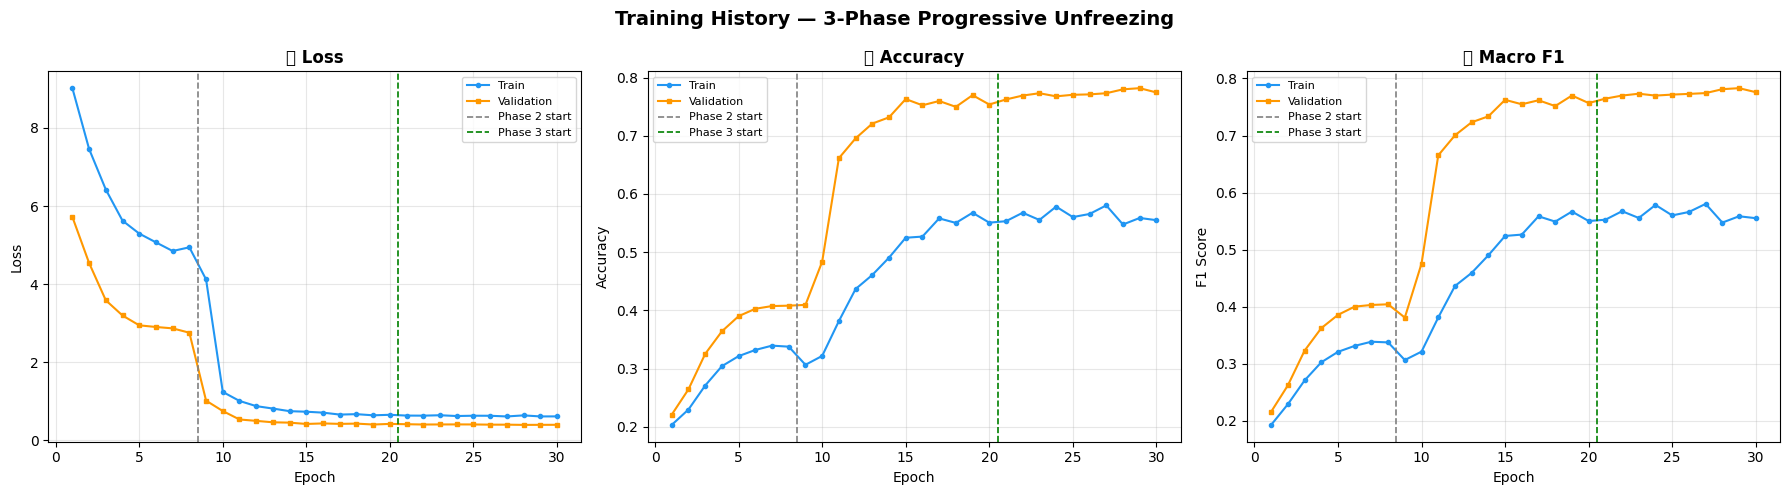

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — LEARNING CURVES
# ═══════════════════════════════════════════════════════════════

banner('TRAINING HISTORY SUMMARY')
print(f'  Total epochs trained : {len(history["tr_loss"])}')
print(f'  Best val F1 (macro)  : {best_f1:.4f}')
print(f'  Best val Accuracy    : {max(history["vl_acc"]):.4f}')
print(f'  Best val Loss        : {min(history["vl_loss"]):.4f}')

epochs_x = range(1, len(history['tr_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cfg = [
    ('tr_loss', 'vl_loss', '📉 Loss',     'Loss'),
    ('tr_acc',  'vl_acc',  '🎯 Accuracy', 'Accuracy'),
    ('tr_f1',   'vl_f1',   '📊 Macro F1', 'F1 Score'),
]
for ax, (tr_k, vl_k, title, ylabel) in zip(axes, plot_cfg):
    ax.plot(epochs_x, history[tr_k], label='Train',      color='#2196F3', marker='o', ms=3)
    ax.plot(epochs_x, history[vl_k], label='Validation', color='#FF9800', marker='s', ms=3)
    ax.axvline(x=p1_end + 0.5, color='gray',  linestyle='--', linewidth=1.2, label=f'Phase 2 start')
    ax.axvline(x=p2_end + 0.5, color='green', linestyle='--', linewidth=1.2, label=f'Phase 3 start')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Training History — 3-Phase Progressive Unfreezing',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — EVALUATION WITH TEST-TIME AUGMENTATION (TTA)
# ═══════════════════════════════════════════════════════════════
#
#  TTA averages softmax logits over N different views of each
#  image at inference time. Typically adds +1–3% F1 for free.
# ──────────────────────────────────────────────────────────────

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

def predict_with_tta(model, df, img_dir, tta_tfs, batch_size=32):
    """Run TTA inference: average logits over all TTA transforms."""
    n = len(df)
    all_logits = torch.zeros(n, NUM_CLASSES)

    for tf_idx, tf in enumerate(tqdm(tta_tfs, desc='TTA views')):
        ds  = CropDiseaseDataset(df, img_dir, transforms=tf)
        dl  = DataLoader(ds, batch_size=batch_size, shuffle=False,
                         num_workers=4, pin_memory=True)
        idx = 0
        with torch.no_grad():
            for imgs, _ in dl:
                logits = model(imgs.to(DEVICE)).cpu()
                bsz    = logits.size(0)
                all_logits[idx:idx + bsz] += logits
                idx += bsz

    return all_logits.argmax(1).numpy()


tta_preds  = predict_with_tta(model, val_df, TRAIN_IMG_DIR, tta_transforms)
all_labels = val_df['label'].tolist()
class_names = [label_map[i] for i in range(NUM_CLASSES)]

banner('CLASSIFICATION REPORT (with TTA)')
print(classification_report(all_labels, tta_preds, target_names=class_names))

# ── F1 comparison: no-TTA vs TTA ─────────────────────────────
from sklearn.metrics import f1_score as sk_f1

# Standard predictions (no TTA) for comparison
all_preds_no_tta = []
with torch.no_grad():
    for imgs, _ in DataLoader(CropDiseaseDataset(val_df, TRAIN_IMG_DIR, val_transforms),
                               batch_size=32, shuffle=False, num_workers=4):
        all_preds_no_tta.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())

f1_no_tta = sk_f1(all_labels, all_preds_no_tta, average='macro')
f1_tta    = sk_f1(all_labels, tta_preds,        average='macro')

banner('TTA IMPACT')
print(f'  F1 without TTA : {f1_no_tta:.4f}  ({f1_no_tta*100:.2f}%)')
print(f'  F1 with TTA    : {f1_tta:.4f}  ({f1_tta*100:.2f}%)')
print(f'  Improvement    : +{(f1_tta - f1_no_tta)*100:.2f} pp')


TTA views: 100%|██████████| 5/5 [01:06<00:00, 13.33s/it]


═════════════════════════════════════════════════════════════════
  CLASSIFICATION REPORT (with TTA)
═════════════════════════════════════════════════════════════════
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.75      0.84      0.79       299
Cassava Brown Streak Disease (CBSD)       0.82      0.74      0.78       299
         Cassava Green Mottle (CGM)       0.82      0.76      0.79       299
       Cassava Mosaic Disease (CMD)       0.87      0.87      0.87       299
                            Healthy       0.66      0.71      0.69       299

                           accuracy                           0.78      1495
                          macro avg       0.79      0.78      0.78      1495
                       weighted avg       0.79      0.78      0.78      1495




═════════════════════════════════════════════════════════════════
  TTA IMPACT
═════════════════════════════════════════════════════════════════
  F1 without TTA : 0.7830  (78.30%)
  F1 with TTA    : 0.7825  (78.25%)
  Improvement    : +-0.05 pp


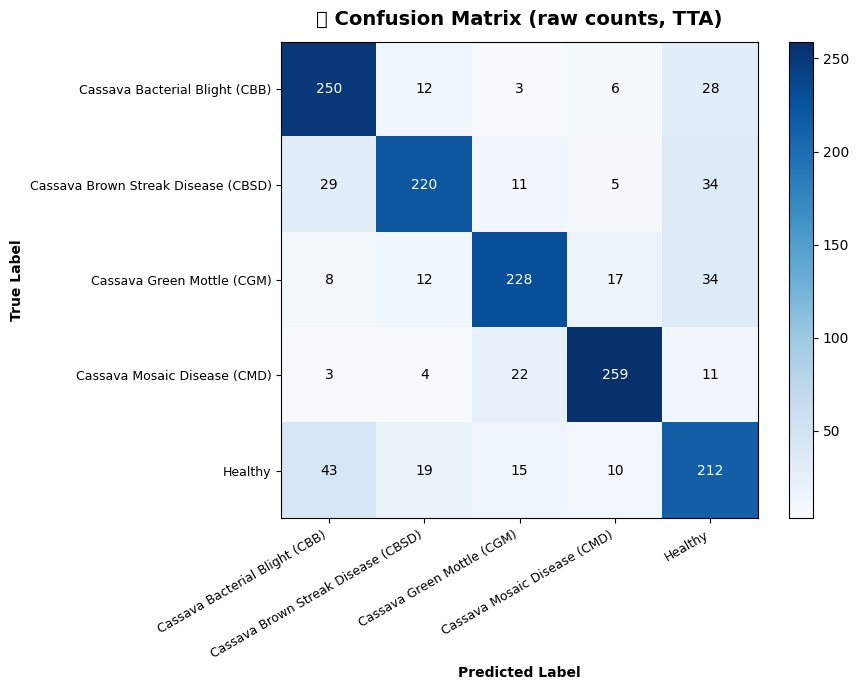

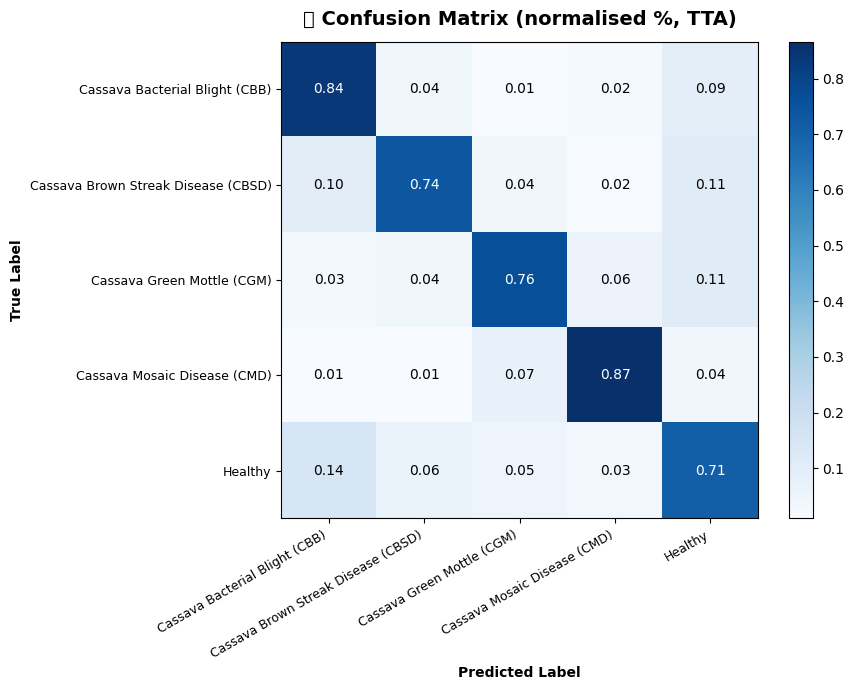

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════

def plot_cm(cm_data, classes, normalize=False, title='Confusion Matrix'):
    if normalize:
        cm_data = cm_data.astype(float) / cm_data.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_data, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(ticks); ax.set_yticklabels(classes, fontsize=9)
    fmt = '.2f' if normalize else 'd'
    thresh = cm_data.max() / 2
    for i, j in itertools.product(range(cm_data.shape[0]), range(cm_data.shape[1])):
        ax.text(j, i, format(cm_data[i, j], fmt), ha='center', va='center', fontsize=10,
                color='white' if cm_data[i, j] > thresh else 'black')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout(); plt.show()

cm = confusion_matrix(all_labels, tta_preds)
plot_cm(cm, class_names, title='🔢 Confusion Matrix (raw counts, TTA)')
plot_cm(cm, class_names, normalize=True, title='📊 Confusion Matrix (normalised %, TTA)')


ValueError: shapes (1280,) and (512,81) not aligned: 1280 (dim 0) != 512 (dim 0)

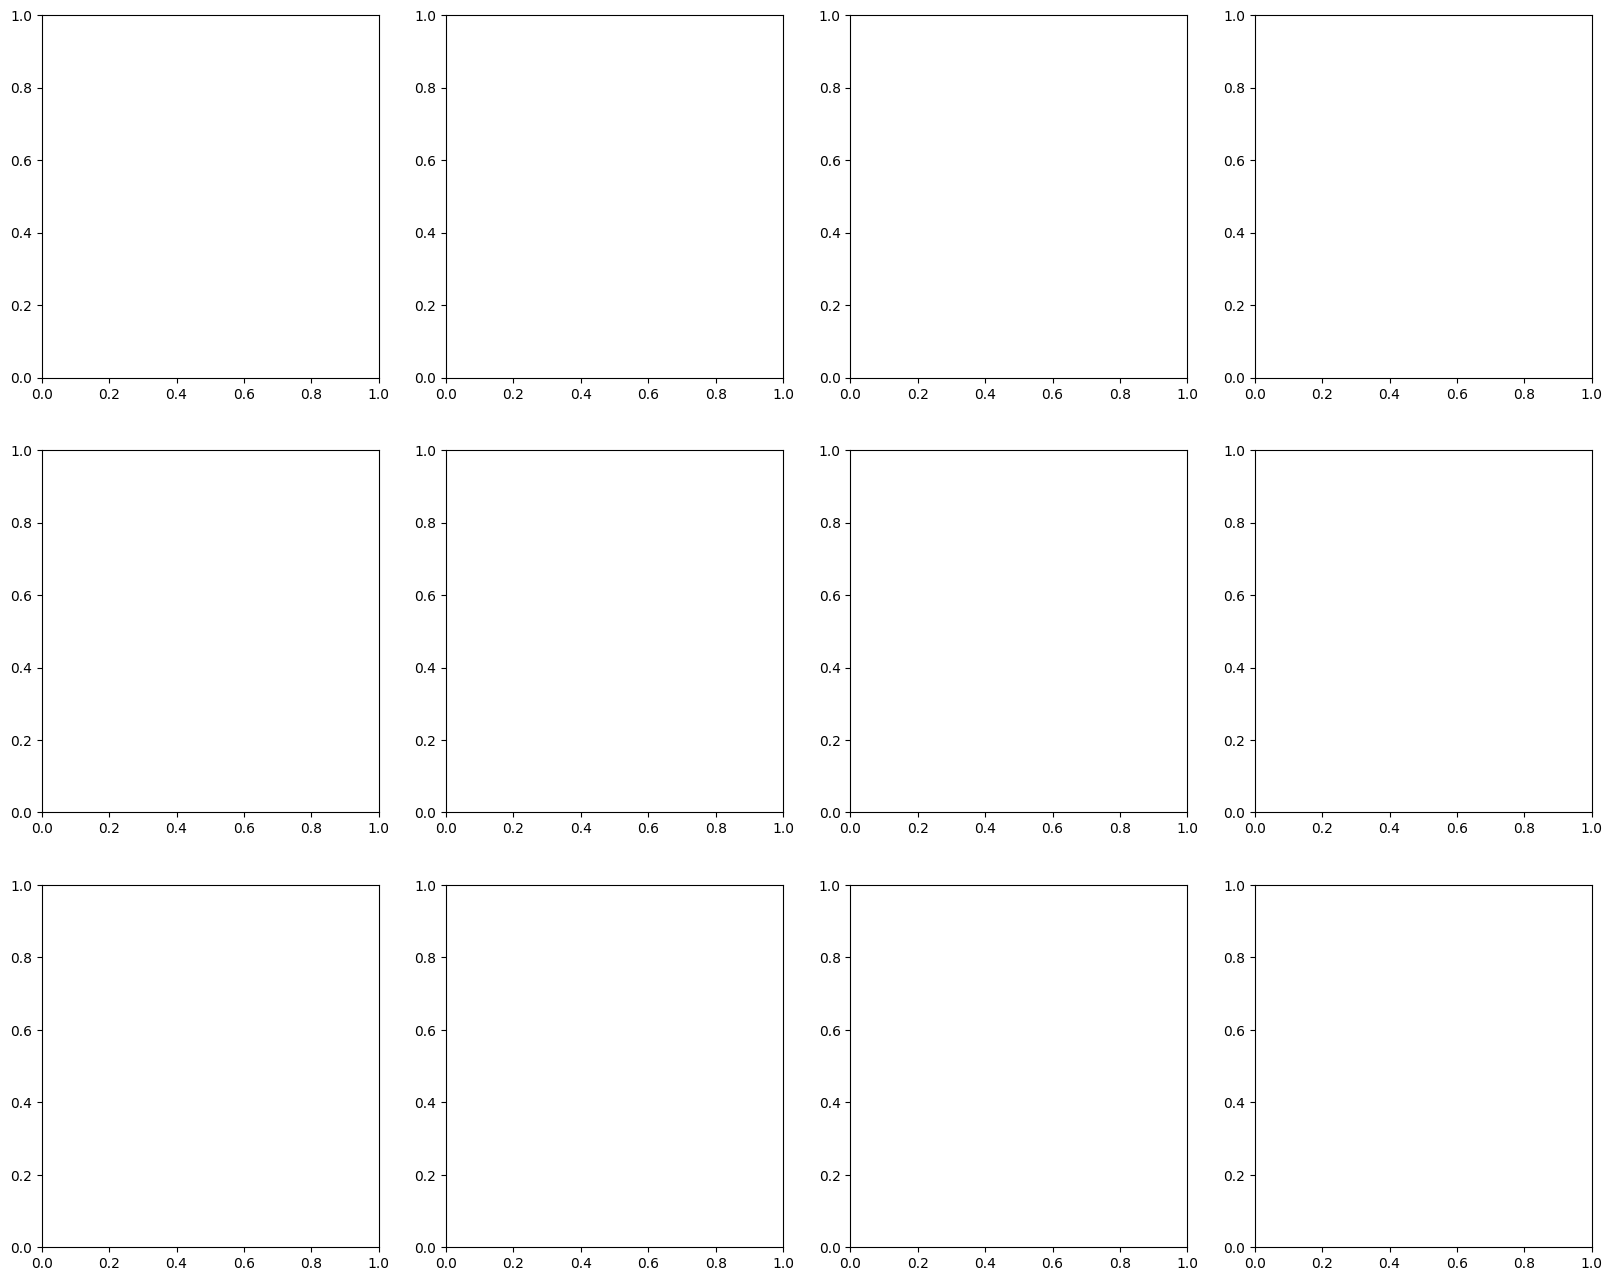

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — GRADCAM VISUALISATION
# ═══════════════════════════════════════════════════════════════

class SaveFeatures:
    features = None
    def __init__(self, module):
        self.hook = module.register_forward_hook(self._hook)
    def _hook(self, _, __, output):
        self.features = output.detach().cpu().numpy()
    def remove(self):
        self.hook.remove()

def get_cam(conv_features, fc_weights, class_idx):
    _, C, H, W = conv_features.shape
    cam = fc_weights[class_idx].dot(conv_features[0].reshape(C, H * W)).reshape(H, W)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def denorm(t):
    inv = T.Compose([
        T.Normalize(mean=[0., 0., 0.], std=[1/s for s in STD]),
        T.Normalize(mean=[-m for m in MEAN], std=[1., 1., 1.])
    ])
    return (inv(t.cpu()).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)


final_conv  = model.blocks[-1]
fc_weights  = list(model.classifier.parameters())[0].detach().cpu().numpy()
activations = SaveFeatures(final_conv)

vis_dl = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=False)

num_vis = 12
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
axes = axes.ravel()
correct_count = wrong_count = 0
model.eval()

for ax_idx, (img_t, gt) in enumerate(vis_dl):
    if ax_idx >= num_vis: break
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
    pred = out.argmax(1).item()
    conf = torch.softmax(out, 1).max().item()
    cam  = get_cam(activations.features, fc_weights, pred)

    raw     = denorm(img_t[0])
    heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    axes[ax_idx].imshow(raw)
    axes[ax_idx].imshow(heatmap, alpha=0.45, cmap='jet')

    is_correct = (pred == gt.item())
    color = 'limegreen' if is_correct else 'red'
    icon  = '✅' if is_correct else '❌'
    if is_correct: correct_count += 1
    else: wrong_count += 1

    axes[ax_idx].set_title(
        f'{icon} GT : {label_map[gt.item()]}\n'
        f'    Pred: {label_map[pred]}  ({conf*100:.1f}%)',
        fontsize=7.5, color=color, fontweight='bold'
    )
    axes[ax_idx].axis('off')

activations.remove()
plt.suptitle('🔥 GradCAM — What is the model looking at? (TTA preds)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'  Shown {num_vis} samples: {correct_count} correct ✅  |  {wrong_count} wrong ❌')


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — SAVE MODEL & FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════

torch.save(model.state_dict(), FINAL_PATH)
print(f'✅ Final model saved  → {FINAL_PATH}')
print(f'✅ Best model saved   → {SAVE_PATH}')

for p in [SAVE_PATH, FINAL_PATH]:
    size_mb = os.path.getsize(p) / 1e6
    print(f'   📦 {os.path.basename(p)}  ({size_mb:.1f} MB)')

final_f1  = f1_tta
final_acc = max(history['vl_acc'])
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2 + EPOCHS_PHASE3

banner('🌿 FINAL SUMMARY  —  HIGH-PERFORMANCE CROP DISEASE CLASSIFIER', char='═', width=68)
print()
print('  📁  DATASET')
print(f'    Original size    : {len(df):>8,} images')
print(f'    Balanced size    : {len(balanced_df):>8,} images  (hybrid sampling)')
print(f'    Train set        : {len(train_df):>8,} images  (85%)')
print(f'    Validation set   : {len(val_df):>8,} images  (15%)')
print()
print('  🧠  MODEL')
print(f'    Architecture     : tf_efficientnetv2_m  (ImageNet-21k pretrained)')
print(f'    Sampling         : Hybrid (oversample minority + undersample majority)')
print(f'    Augmentation     : RandAugment + MixUp + CutMix + RandomErasing')
print(f'    Loss             : FocalLoss(γ=2) + LabelSmoothing({LABEL_SMOOTHING})')
print(f'    Optimizer        : AdamW  |  Schedule: OneCycleLR + CosineAnnealingLR')
print(f'    Phase 1 epochs   : {EPOCHS_PHASE1}  (head only)')
print(f'    Phase 2 epochs   : {EPOCHS_PHASE2}  (top 4 blocks + head)')
print(f'    Phase 3 epochs   : {EPOCHS_PHASE3}  (full model, differential LR)')
print(f'    Total epochs     : {total_epochs}')
print(f'    TTA views        : {len(tta_transforms)}')
print()
print('  📊  RESULTS')
print(f'    Best val F1 (no TTA)  : {f1_no_tta:.4f}   ({f1_no_tta*100:.2f}%)')
print(f'    Best val F1 (TTA)     : {final_f1:.4f}   ({final_f1*100:.2f}%)')
print(f'    Best val Accuracy     : {final_acc:.4f}   ({final_acc*100:.2f}%)')
print()
print('  ═' * 34)
print(f'  🏆  FINAL  VAL  F1  (TTA)  =  {final_f1:.4f}  ({final_f1*100:.2f}%)')
print('  ═' * 34)


✅ Final model saved  → /kaggle/working/crop_final.pth
✅ Best model saved   → /kaggle/working/best_crop_model.pth
   📦 best_crop_model.pth  (213.0 MB)
   📦 crop_final.pth  (213.0 MB)

════════════════════════════════════════════════════════════════════
  🌿 FINAL SUMMARY  —  HIGH-PERFORMANCE CROP DISEASE CLASSIFIER
════════════════════════════════════════════════════════════════════

  📁  DATASET
    Original size    :   17,938 images
    Balanced size    :    9,965 images  (hybrid sampling)
    Train set        :    8,470 images  (85%)
    Validation set   :    1,495 images  (15%)

  🧠  MODEL
    Architecture     : tf_efficientnetv2_m  (ImageNet-21k pretrained)
    Sampling         : Hybrid (oversample minority + undersample majority)
    Augmentation     : RandAugment + MixUp + CutMix + RandomErasing
    Loss             : FocalLoss(γ=2) + LabelSmoothing(0.05)
    Optimizer        : AdamW  |  Schedule: OneCycleLR + CosineAnnealingLR
    Phase 1 epochs   : 8  (head only)
    Phase 2 epo